In [52]:
!pip install tensorflow

In [53]:
import tensorflow

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [55]:
data=pd.read_csv("galaxyquasar.csv", sep=",")

In [56]:
u_g=data['u']-data['g']
g_r=data['g']-data['r']
r_i=data['r']-data['i']
i_z=data['i']-data['z']
z=data['z1']

In [57]:
y=np.zeros(len(data['class']))
y[data['class']=='QSO']=1

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X=np.array([u_g,g_r,r_i,i_z])
X=X.transpose()

sc = StandardScaler()
Xs = sc.fit_transform(X)

X_train_full, X_test = train_test_split(Xs, test_size=0.2, random_state=42)
y_train_full, y_test = train_test_split(y, test_size=0.2, random_state=42)


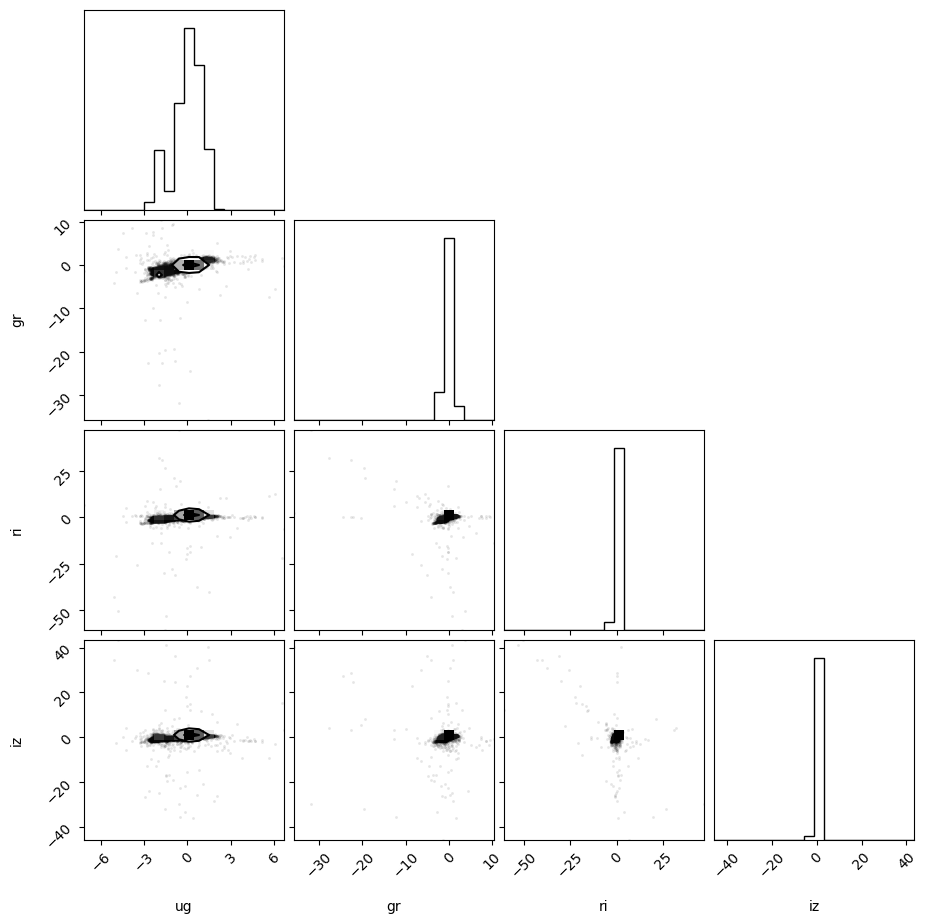

In [58]:
!pip install corner
import corner
corner.corner(X_train_full, labels=['ug', 'gr', 'ri', 'iz']);

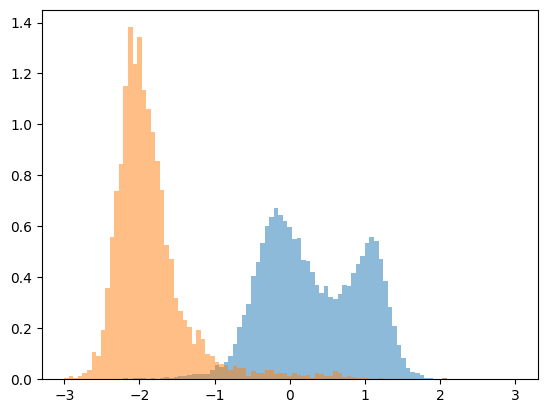

In [59]:
plt.hist(X_train_full[:,0][y_train_full==0], bins=np.linspace(-3,3,100), density=True, alpha=0.5)
plt.hist(X_train_full[:,0][y_train_full==1], bins=np.linspace(-3,3,100), density=True, alpha=0.5);

In [60]:
from tensorflow import keras

In [61]:
import tensorflow as tf

keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [62]:
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_train = X_train[:, :, np.newaxis]
X_valid = X_valid[:, :, np.newaxis]
X_test = X_test[:, :, np.newaxis]


In [63]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=64, kernel_size=7, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=1),
    keras.layers.Conv1D(256, 3, activation='relu', padding='same'),
    keras.layers.Conv1D(256, 3, activation='relu', padding='same'),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [64]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 64)          │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 2, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 444,490 (1.70 MB)

 Trainable params: 444,490 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

None


In [65]:
model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.9506 - loss: 0.2909 - val_accuracy: 0.9836 - val_loss: 0.0826
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.9814 - loss: 0.0933 - val_accuracy: 0.9848 - val_loss: 0.0598
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.9833 - loss: 0.0755 - val_accuracy: 0.9848 - val_loss: 0.0559
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.9845 - loss: 0.0677 - val_accuracy: 0.9834 - val_loss: 0.0548
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9849 - loss: 0.0651 - val_accuracy: 0.9832 - val_loss: 0.0542
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.9847 - loss: 0.0621 - val_accuracy: 0.9844 - val_loss: 0.0500
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.9857 - loss: 0.0594 - val_accuracy: 0.9830 - val_loss: 0.0538
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9857 -

In [66]:
import sklearn
y_pred=np.argmax(model.predict(X_test), axis=-1)
print(sklearn.metrics.confusion_matrix(y_pred, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[8493   78]
 [  79 1350]]


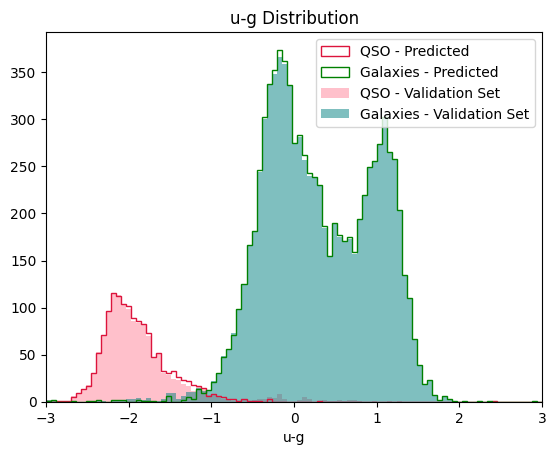

In [67]:
plt.hist(X_test[:,0][y_pred==1],color='crimson',histtype='step',bins=np.linspace(-3,3,100),label='QSO - Predicted')
plt.hist(X_test[:,0][y_pred==0],color='green',histtype='step',bins=np.linspace(-3,3,100),label='Galaxies - Predicted')
plt.xlim(-3,3)
plt.legend();

plt.hist(X_test[:,0][y_test==1],color='pink',bins=np.linspace(-3,3,100), label='QSO - Validation Set');
plt.hist(X_test[:,0][y_test==0],color='teal',alpha=0.5,bins=np.linspace(-3,3,100), label='Galaxies - Validation Set');
plt.title("u-g Distribution")
plt.xlabel('u-g')
plt.legend();

In [68]:
!pip install astroML
from astroML.utils import completeness_contamination
completeness, contamination= completeness_contamination(y_pred,y_test)

In [69]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_test))))[:,1]
y_prob.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


(10000,)

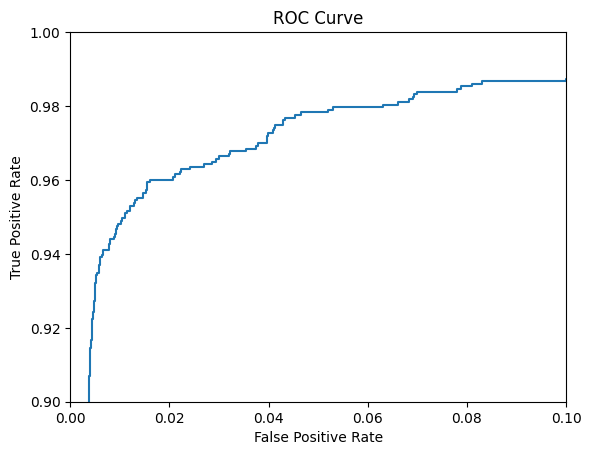

In [70]:
from sklearn.metrics import precision_recall_curve, roc_curve

fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate");

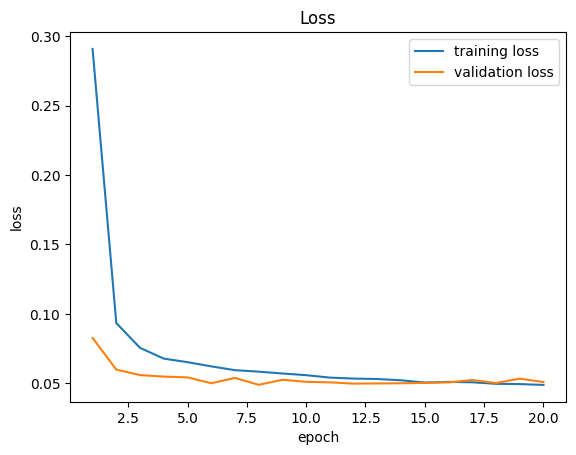

In [71]:
last_epoch = len(clf.history['loss'])
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss')
plt.legend();

Max Accuracy:0.9854000210762024


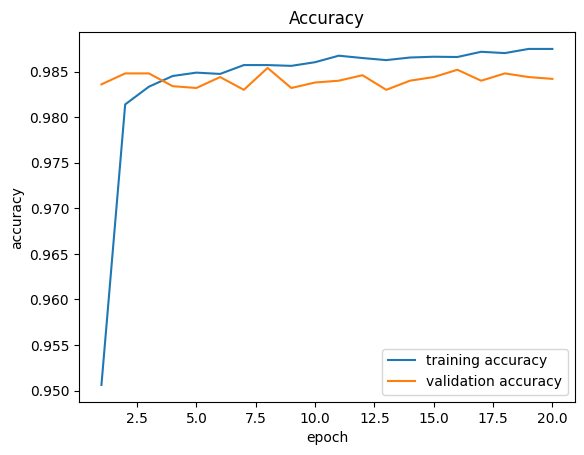

In [72]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy')
plt.legend();
print("Max Accuracy:"+str(np.max(clf.history['val_accuracy'])))

Let's see what happens without dimensionality reduction and with an overall easier model!

In [73]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=32, kernel_size=7, activation='relu', padding='same'),
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [74]:
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 4, 32)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,162 (35.79 KB)

 Trainable params: 9,162 (35.79 KB)

 Non-trainable params: 0 (0.00 B)

None


In [75]:
model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8378 - loss: 0.8840 - val_accuracy: 0.9764 - val_loss: 0.1848
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9540 - loss: 0.1761 - val_accuracy: 0.9814 - val_loss: 0.1077
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9688 - loss: 0.1264 - val_accuracy: 0.9812 - val_loss: 0.0900
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9732 - loss: 0.1109 - val_accuracy: 0.9816 - val_loss: 0.0826
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9754 - loss: 0.1045 - val_accuracy: 0.9820 - val_loss: 0.0796
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9767 - loss: 0.1006 - val_accuracy: 0.9822 - val_loss: 0.0781
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9769 - loss: 0.0964 - val_accuracy: 0.9822 - val_loss: 0.0773
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9785 - loss: 0.0952 -

In [76]:
import sklearn
y_pred=np.argmax(model.predict(X_test), axis=-1)
print(sklearn.metrics.confusion_matrix(y_pred, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[8510  105]
 [  62 1323]]


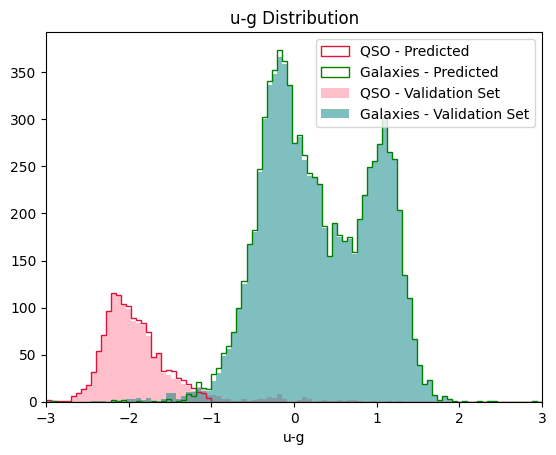

In [77]:
plt.hist(X_test[:,0][y_pred==1],color='crimson',histtype='step',bins=np.linspace(-3,3,100),label='QSO - Predicted')
plt.hist(X_test[:,0][y_pred==0],color='green',histtype='step',bins=np.linspace(-3,3,100),label='Galaxies - Predicted')
plt.xlim(-3,3)
plt.legend();

plt.hist(X_test[:,0][y_test==1],color='pink',bins=np.linspace(-3,3,100), label='QSO - Validation Set');
plt.hist(X_test[:,0][y_test==0],color='teal',alpha=0.5,bins=np.linspace(-3,3,100), label='Galaxies - Validation Set');
plt.title("u-g Distribution")
plt.xlabel('u-g')
plt.legend();

In [78]:
!pip install astroML
from astroML.utils import completeness_contamination
completeness, contamination= completeness_contamination(y_pred,y_test)

In [79]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_test))))[:,1]
y_prob.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000,)

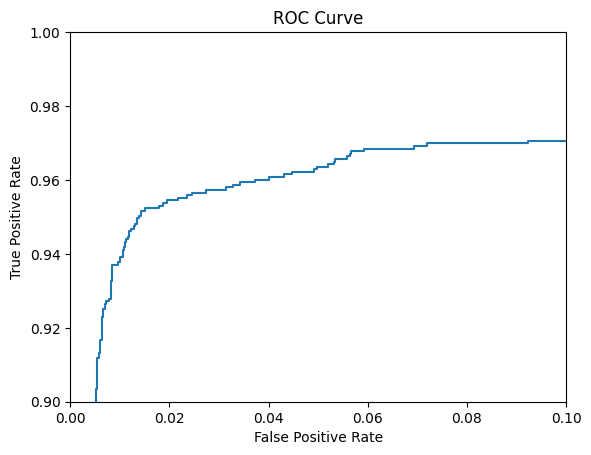

In [80]:
from sklearn.metrics import precision_recall_curve, roc_curve

fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate");

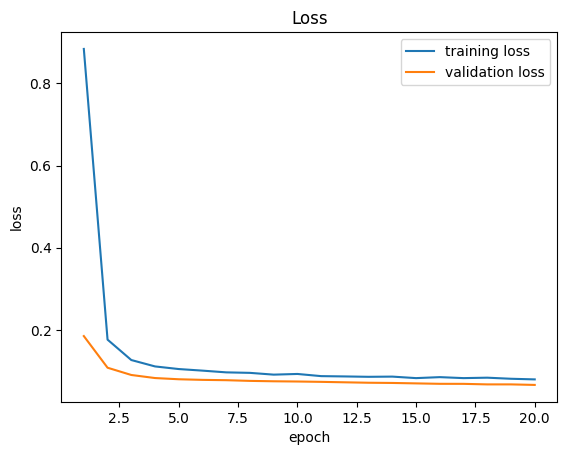

In [81]:
last_epoch = len(clf.history['loss'])
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss')
plt.legend();

Max Accuracy:0.9833999872207642


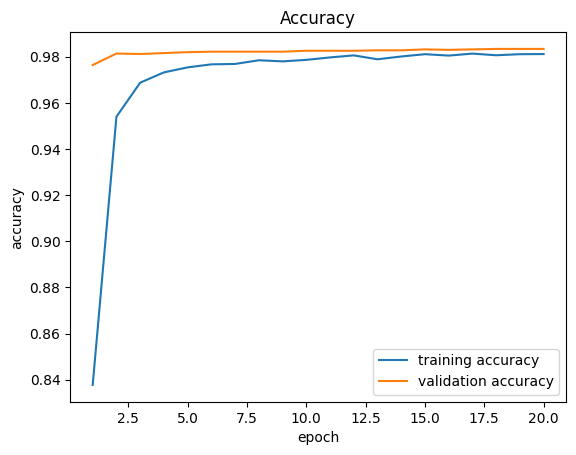

In [82]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy')
plt.legend();
print("Max Accuracy:"+str(np.max(clf.history['val_accuracy'])))

Despite an easier model, we arrive at a very high accuracy!

# Learning Rate Cross Validation



In [83]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=32, kernel_size=7, activation='relu', padding='same'),
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

learning_rates=[1e-5,1e-4,1e-3,1e-2,0.1]

for i in range(len(learning_rates)):
  model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=learning_rates[i]), metrics=["accuracy"])
  clf = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

  y_pred=np.argmax(model.predict(X_test), axis=-1)
  print(sklearn.metrics.confusion_matrix(y_pred, y_test))
  print("Max Accuracy:"+str(np.max(clf.history['val_accuracy']))+"with learning rate "+str(learning_rates[i]))

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4194 - loss: 2.1390 - val_accuracy: 0.8558 - val_loss: 1.9666
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8065 - loss: 1.7281 - val_accuracy: 0.8570 - val_loss: 1.4600
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8645 - loss: 1.2406 - val_accuracy: 0.8712 - val_loss: 0.9780
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8756 - loss: 0.8614 - val_accuracy: 0.9150 - val_loss: 0.6700
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8857 - loss: 0.6184 - val_accuracy: 0.9634 - val_loss: 0.4801
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8937 - loss: 0.4703 - val_accuracy: 0.9702 - val_loss: 0.3598
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9047 - loss: 0.3701 - val_accuracy: 0.9702 - val_loss: 0.2819
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9180 - loss: 0.3063 - val_accurac

So the learning rate with the highest accuracy is 0.001

In [84]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=32, kernel_size=7, activation='relu', padding='same'),
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.001), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

y_pred=np.argmax(model.predict(X_test), axis=-1)
print(sklearn.metrics.confusion_matrix(y_pred, y_test))
print("Max Accuracy:"+str(np.max(clf.history['val_accuracy'])))

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9597 - loss: 0.1909 - val_accuracy: 0.9826 - val_loss: 0.0713
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9790 - loss: 0.0911 - val_accuracy: 0.9836 - val_loss: 0.0664
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9808 - loss: 0.0807 - val_accuracy: 0.9844 - val_loss: 0.0625
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9817 - loss: 0.0769 - val_accuracy: 0.9846 - val_loss: 0.0587
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9820 - loss: 0.0737 - val_accuracy: 0.9842 - val_loss: 0.0559
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9825 - loss: 0.0710 - val_accuracy: 0.9844 - val_loss: 0.0555
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9827 - loss: 0.0702 - val_accuracy: 0.9848 - val_loss: 0.0544
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9836 - loss: 0.0664 - val_accura

In [85]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_test))))[:,1]
y_prob.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


(10000,)

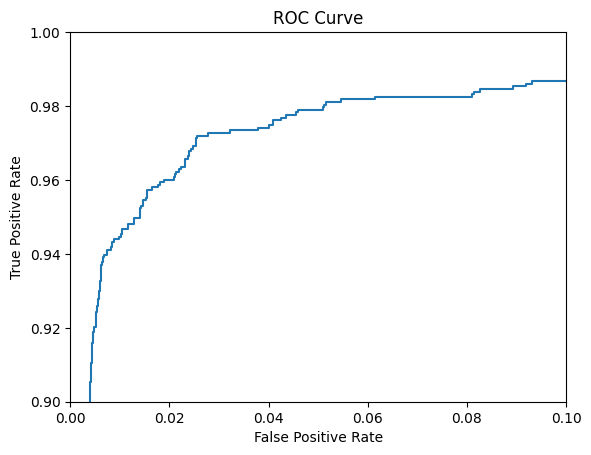

In [86]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate");